In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [3]:
load_dotenv()

False

In [ ]:
model = ChatOpenAI(model = 'gpt-4o-mini')

In [5]:
class SentimentSchema(BaseModel):
    sentiment : Literal["positive", "negative"] = Field(description = 'Sentiment of the review')

In [7]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description = 'The category of the issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description = "The tone of the review that is being mentioned")
    urgency: Literal["low", "medium", "high"] = Field(description = "how urgent or critical the issue being mentioned in the review is")
    

In [8]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

NameError: name 'model' is not defined

In [ ]:
prompt = "what is the sentiment of the folowing review- the software is good"
structured_model.invoke(prompt).sentiment

In [9]:
class ReviewState(TypedDict):

    review : str
    sentiment : Literal["positive", "negative"]
    diagnosis : dict
    response : str

In [15]:
def find_sentiment(state: ReviewState):
    prompt = f"for the following review find out the sentiment in {state['review']}"
    sentiment = structured_model.invoke(prompt).sentiment
    return {"sentiment" : sentiment}


def check_sentiment(state: ReviewState) -> Literal["positive_response", "negative_response"]:
    if state["sentiment"] == 'positive':
        return "positive_sentiment"
    else:
        return "run_diagnosis"

def positive_response(state: ReviewState):
    prompt = f"""write a warm thank you message for the review received by
    us in this {state["review"]}, also kindly ask the user for a positive review on our website"""

    response = model.invoke(prompt).content

    return {"response" :response}

def run_diagnosis(state: ReviewState):
    prompt = f"""diagnose this negative review {state["review"]} return the tone urgency, tone and the issue_type"""

    response = structured_model2.invoke(prompt)
    return {'diagnosis' : reponse.model_dump()}

def negative_response(state:ReviewState):

    diagnosis = state["diagnosis"]

    prompt = f"""you are a smart diagnostic tool - review the {diagnosis} and use the keys and values of it to formulate an emphatetic, kind and soft sounding response to the review"""

    response = model.invoke(prompt).content

    return {'response' : reponse}

In [19]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment' , find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)


graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

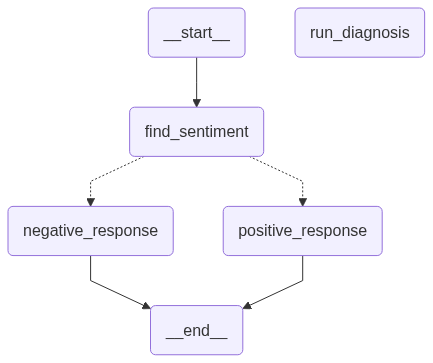

In [20]:
workflow